In [2]:
!pip install -q langsmith openevals langchain langchain-groq langchain-community langgraph yfinance wikipedia google-search-results

Where to create a LangSmith API Key?
- Go to : https://smith.langchain.com/
- Create your account.
- Click on "Get started with Tracing".
- Click on "Generate API Key" button.

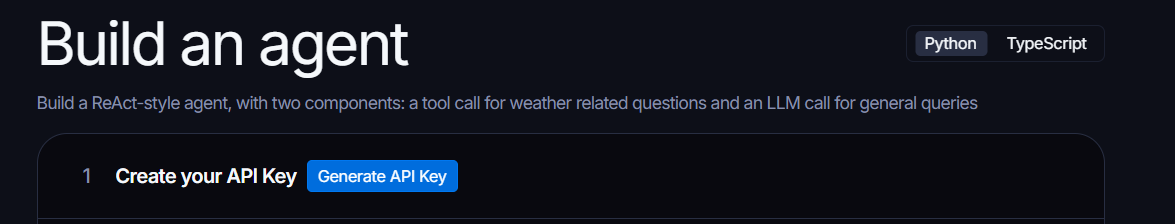

In [3]:
import os

os.environ["LANGSMITH_TRACING"]  = "true"
os.environ["LANGSMITH_PROJECT"]  = "finbot-lecture-observability"

In [4]:
import getpass

if "LANGSMITH_API_KEY" not in os.environ:
    os.environ["LANGSMITH_API_KEY"] = getpass.getpass("Enter your LangSmith API key: ")

Enter your LangSmith API key: ··········


In [5]:
if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")

Enter your Groq API key: ··········


In [6]:
if "SERPAPI_API_KEY" not in os.environ:
    os.environ["SERPAPI_API_KEY"] = getpass.getpass("Enter your SerpAPI API key: ")

Enter your SerpAPI API key: ··········


In [7]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
)

In [8]:
import yfinance as yf
from langchain.tools import tool

@tool
def get_stock_fundamentals(ticker: str) -> dict:
    """Get current stock price, P/E ratio, market cap, and revenue growth for a ticker."""
    stock = yf.Ticker(ticker)
    info = stock.info
    return {
        "price": info.get("currentPrice"),
        "pe_ratio": info.get("trailingPE"),
        "market_cap": info.get("marketCap"),
        "revenue_growth": info.get("revenueGrowth"),
        "52w_high": info.get("fiftyTwoWeekHigh"),
        "52w_low": info.get("fiftyTwoWeekLow"),
    }

In [9]:
from langchain_community.utilities import SerpAPIWrapper

serp = SerpAPIWrapper(
    serpapi_api_key=os.getenv("SERPAPI_API_KEY"),
    params={
        "tbm": "nws",     # Search in Google News
        "tbs": "qdr:d",   # Past day (24 hours)
    },
)

@tool
def search_news(query: str) -> str:
    """
    Search last-24h Google News via SerpAPI.
    Returns news results with URLs.
    """
    return serp.run(query)

In [10]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.tools.yahoo_finance_news import YahooFinanceNewsTool


tools = [
    get_stock_fundamentals,
    YahooFinanceNewsTool(),
    WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper()),
    search_news
]

In [11]:
!pip install langgraph-checkpoint-sqlite

In [12]:
from langchain.agents import create_agent
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

conn = sqlite3.connect("finance_agent.db", check_same_thread=False)
checkpointer = SqliteSaver(conn)

SYSTEM_PROMPT = """
You are FinBot, an expert equity research analyst with deep knowledge of financial markets,
valuation methodologies, and macroeconomic trends.

## Task
Given a stock ticker or company name, produce a concise, structured analyst brief that helps users evaluate the investment. Do not give buy/sell advice. Present data-driven signals only.

## Rules
1. Gather data before analysis. Never rely on memory for numbers.
2. If a tool fails or returns empty data, state it and proceed.
3. Never fabricate prices, ratios, or news.
4. Always follow the output format.
5. Flag notable risks or red flags.

## Output Format

**[TICKER] — Analyst Brief**
- 📊 **Fundamentals:** price, P/E, market cap, revenue growth (one line)
- 📈 **Valuation Signal:** OVERVALUED / FAIRLY VALUED / UNDERVALUED + reason
- 📰 **News Sentiment:** bullish / neutral / bearish + key headline
- ⚠️ **Key Risks:** 1–2 bullets
- 🧭 **Outlook:** 1–2 sentence synthesis, no advice
"""

my_finance_agent = create_agent(
    model= llm,
    tools=tools,
    system_prompt=SYSTEM_PROMPT,
    checkpointer=checkpointer
)

In [13]:
config = {"configurable": {"thread_id": "user-alice-session-1"}}

agent_trace = my_finance_agent.invoke(
    {"messages": [{"role": "user", "content": "Give me a quick analyst brief on NVDA. Is now a good time to buy?"}]},
    config
)

print(agent_trace["messages"][-1].content)

**NVDA — Analyst Brief**  
- 📊 **Fundamentals:** $167.52, P/E ≈ 34.1, market cap ≈ $4.07 T, revenue growth ≈ 73.2% YoY  
- 📈 **Valuation Signal:** FAIRLY VALUED – the P/E is above the S&P 500 average, but the company’s high revenue growth and margin expansion justify a premium.  
- 📰 **News Sentiment:** bullish – recent coverage highlights strong AI demand, positive earnings outlook, and a view that NVDA is “cheaper than the S&P 500” on forward P/E.  
- ⚠️ **Key Risks:**  
  1. **Valuation pressure** – a pullback in AI‑related demand could compress the premium.  
  2. **Competitive landscape** – rapid advances from rivals (AMD, Intel, emerging AI‑chip startups) could erode market share.  
- 🧭 **Outlook:** NVDA continues to benefit from accelerating AI and data‑center revenue streams, but investors should monitor valuation dynamics and competitive developments.


### **Traceable Decorator**

The `@traceable` decorator helps in tracing any function call with langsmith.

Core components of LangSmith Tracing:

- **Run:**  A single unit of work or operation in our LLM application (eg. tool call or llm call).

- **Trace:** A trace is a collection of Runs for a single chain.

- **Thread:** All the traces for a single multi-turn conversation.

- **Project:** A project is a collection of traces.

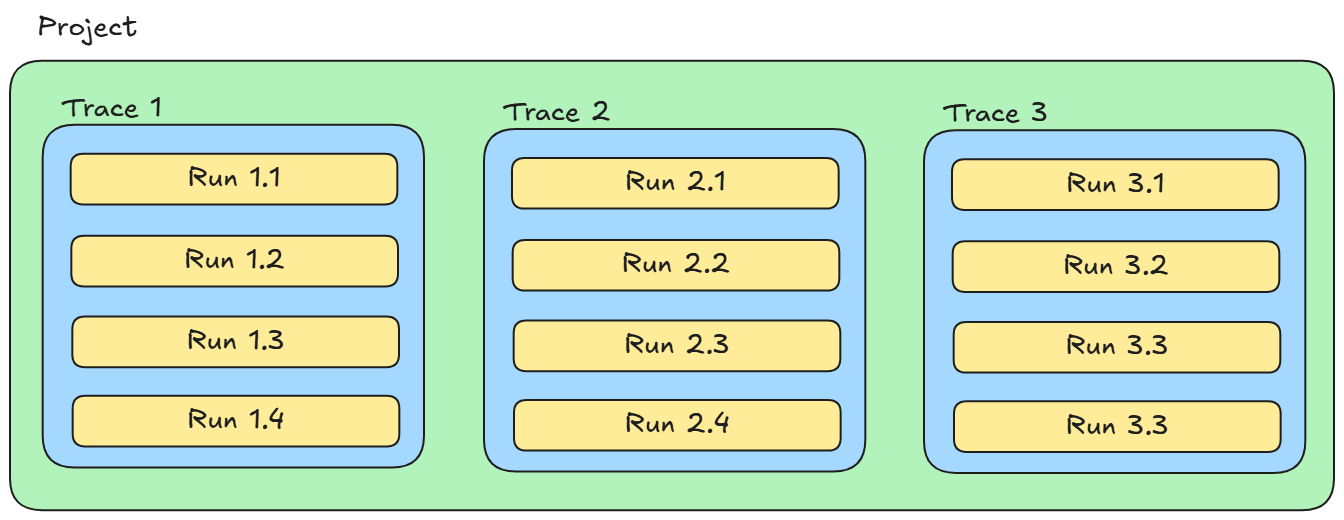

In [15]:
from langsmith import traceable

@traceable(name="FinBot: Full Stock Brief", run_type="chain")
def run_finance_brief(ticker: str, thread_id: str) -> str:
    """Top-level wrapper — becomes the root span in LangSmith."""
    config = {"configurable": {"thread_id": thread_id}}
    result = my_finance_agent.invoke(
        {"messages": [{"role": "user", "content": f"Give me a full brief on {ticker}"}]},
        config
    )
    return result["messages"][-1].content

run_finance_brief("NVDA", "trace-demo-1")

'**NVDA — Analyst Brief**  \n- 📊 **Fundamentals:** $167.52, P/E\u202f≈\u202f34.1, market cap\u202f≈\u202f$4.07\u202fT, revenue growth\u202f≈\u202f73.2% YoY  \n- 📈 **Valuation Signal:** FAIRLY VALUED – the high P/E is offset by strong revenue acceleration and a dominant position in AI/GPUs.  \n- 📰 **News Sentiment:** bullish – “Nvidia Won’t Be Dead Money For Much Longer” highlights accelerating fundamentals and expanding margins.  \n- ⚠️ **Key Risks:**  \n  1. Market pullback or broader tech sell‑off could compress valuation.  \n  2. Regulatory scrutiny on AI and semiconductor supply chains may impact growth.  \n- 🧭 **Outlook:** Nvidia’s robust revenue growth and leadership in AI hardware support continued upside, though valuation remains sensitive to macro‑market swings and regulatory developments.'

### A simple langchain tool to calculate valuation metrics.

In [16]:
import yfinance as yf
from langchain.tools import tool

@tool
def calculate_valuation_metrics(ticker: str) -> dict:
    """Calculate valuation signals: P/E premium vs sector,
    52-week price position, and a simple buy/hold/sell signal.
    Use this to reason about whether a stock is overvalued or undervalued."""
    info = yf.Ticker(ticker).info
    pe       = info.get("trailingPE") or 0
    price    = info.get("currentPrice") or 0
    high_52  = info.get("fiftyTwoWeekHigh") or 1
    low_52   = info.get("fiftyTwoWeekLow") or 0
    sector_pe_benchmarks = {
        "Technology": 28.5, "Healthcare": 22.0,
        "Finance": 14.0,    "Consumer Cyclical": 18.0,
    }
    sector      = info.get("sector", "Technology")
    sector_avg  = sector_pe_benchmarks.get(sector, 20.0)
    pe_premium  = round((pe - sector_avg) / sector_avg * 100, 1) if pe else None
    price_pos   = round((price - low_52) / (high_52 - low_52) * 100, 1) if high_52 != low_52 else None
    signal = (
        "OVERVALUED"    if (pe_premium or 0) > 40  else
        "UNDERVALUED"   if (pe_premium or 0) < -20 else
        "FAIRLY VALUED"
    )
    return {
        "pe_premium_vs_sector_pct":          pe_premium,
        "price_position_in_52w_range_pct":   price_pos,
        "sector":                            sector,
        "sector_avg_pe":                     sector_avg,
        "signal":                            signal,
    }

**Tracing with tags and metadata**

In langsmith we can filter, group, and compare runs by any tag or metadata key.

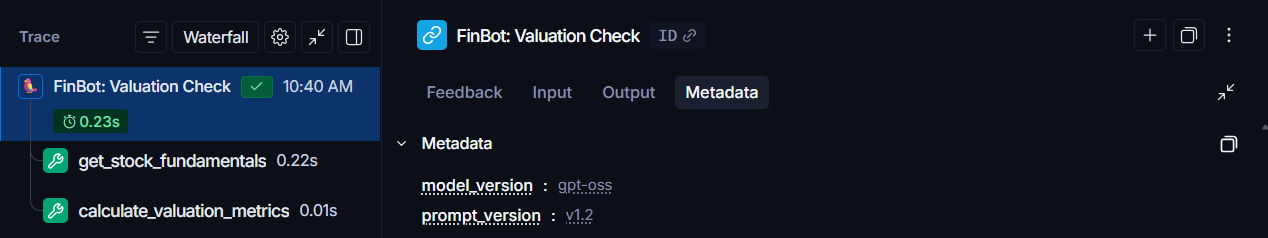

In [17]:
@traceable(
    name        = "FinBot: Valuation Check",
    run_type    = "chain",
    tags        = ["valuation", "v1.2", "test"],
    metadata    = {
        "model_version"  : "gpt-oss",
        "prompt_version" : "v1.2",
        "environment"    : "test",
    }
)
def run_valuation_check(ticker: str) -> dict:
    """Fetch and compute valuation metrics for a ticker."""
    fundamentals = get_stock_fundamentals.invoke(ticker)
    valuation    = calculate_valuation_metrics.invoke(ticker)
    return {"ticker": ticker, "fundamentals": fundamentals, "valuation": valuation}

run_valuation_check("AAPL")

{'ticker': 'AAPL',
 'fundamentals': {'price': 248.8,
  'pe_ratio': 31.453857,
  'market_cap': 3656844050432,
  'revenue_growth': 0.157,
  '52w_high': 288.62,
  '52w_low': 169.21},
 'valuation': {'pe_premium_vs_sector_pct': 10.4,
  'price_position_in_52w_range_pct': 66.7,
  'sector': 'Technology',
  'sector_avg_pe': 28.5,
  'signal': 'FAIRLY VALUED'}}

**Dynamically mutating the run tree mid-execution**

In [18]:
import langsmith as ls

@traceable(name="FinBot: Risk Assessment")
def assess_risk(ticker: str) -> dict:
    result = calculate_valuation_metrics.invoke(ticker)

    # Attach computed signal to the trace span in real time
    rt = ls.get_current_run_tree()
    rt.metadata["valuation_signal"] = result.get("signal")
    rt.metadata["pe_premium"]       = result.get("pe_premium_vs_sector_pct")
    rt.tags.extend([result.get("signal", "UNKNOWN").lower()])

    return result

assess_risk("TSLA")

{'pe_premium_vs_sector_pct': 1744.2,
 'price_position_in_52w_range_pct': 51.9,
 'sector': 'Consumer Cyclical',
 'sector_avg_pe': 18.0,
 'signal': 'OVERVALUED'}

### **Nesting `@traceable` spans**

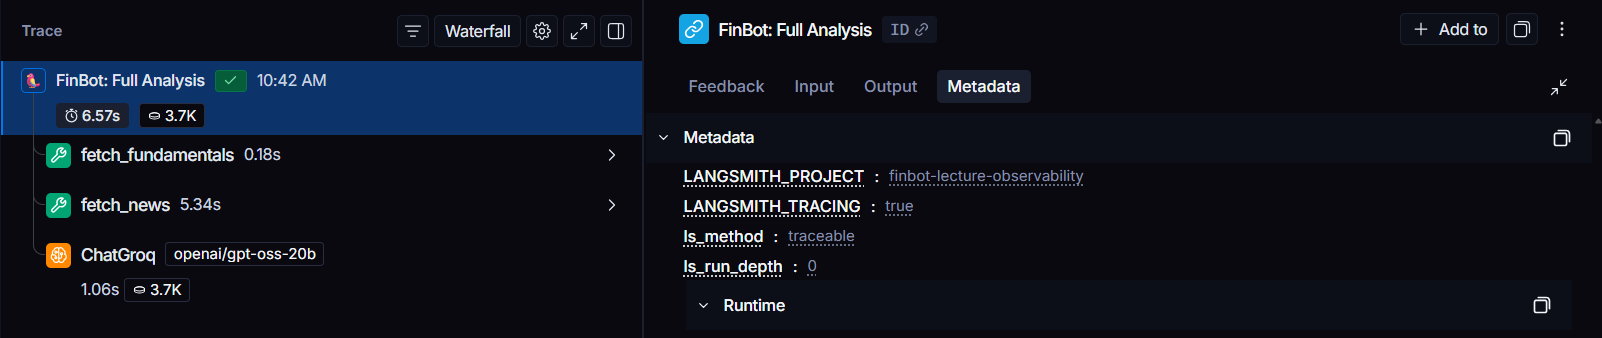

In [19]:
@traceable(name="fetch_fundamentals", run_type="tool")
def fetch_fundamentals(ticker: str) -> dict:
    return get_stock_fundamentals.invoke(ticker)

@traceable(name="fetch_news", run_type="tool")
def fetch_news(ticker: str) -> str:
    return search_news.invoke(ticker)

@traceable(name="FinBot: Full Analysis", run_type="chain")
def full_analysis(ticker: str) -> str:
    fundamentals = fetch_fundamentals(ticker)   # ← child span
    news         = fetch_news(ticker)           # ← child span
    summary      = llm.invoke(
        f"Summarise this analysis for {ticker}: {fundamentals} | News: {news}"
    )
    return summary.content

full_analysis("MSFT")

'**Microsoft Corp. (MSFT) – Quick Snapshot (as of 2026‑03‑27)**  \n\n| Metric | Value | Context |\n|--------|-------|---------|\n| **Current price** | **$356.77** | Trading near the 52‑week low of $344.79; just above the 52‑week high of $555.45. |\n| **P/E ratio** | **22.33** | Reasonably priced relative to the broader market; below the historical average for large‑cap tech (~25‑30). |\n| **Market cap** | **$2.65\u202ftrillion** | One of the largest companies in the world; still a dominant player in cloud, productivity, and AI. |\n| **Revenue growth (YoY)** | **+16.7\u202f%** | Strong top‑line momentum, driven by Azure, Office 365, and AI‑enabled services. |\n| **52‑week range** | **$344.79 – $555.45** | Current price sits ~3\u202f% above the low, indicating a steep decline from the peak. |\n\n---\n\n### Recent News & Sentiment\n\n| Source | Key Takeaway | Tone |\n|--------|--------------|------|\n| **TheStreet (Jim Cramer)** | Cramer flags MSFT as an “unexpected laggard” amid a broade

## **Datasets in LangSmith**

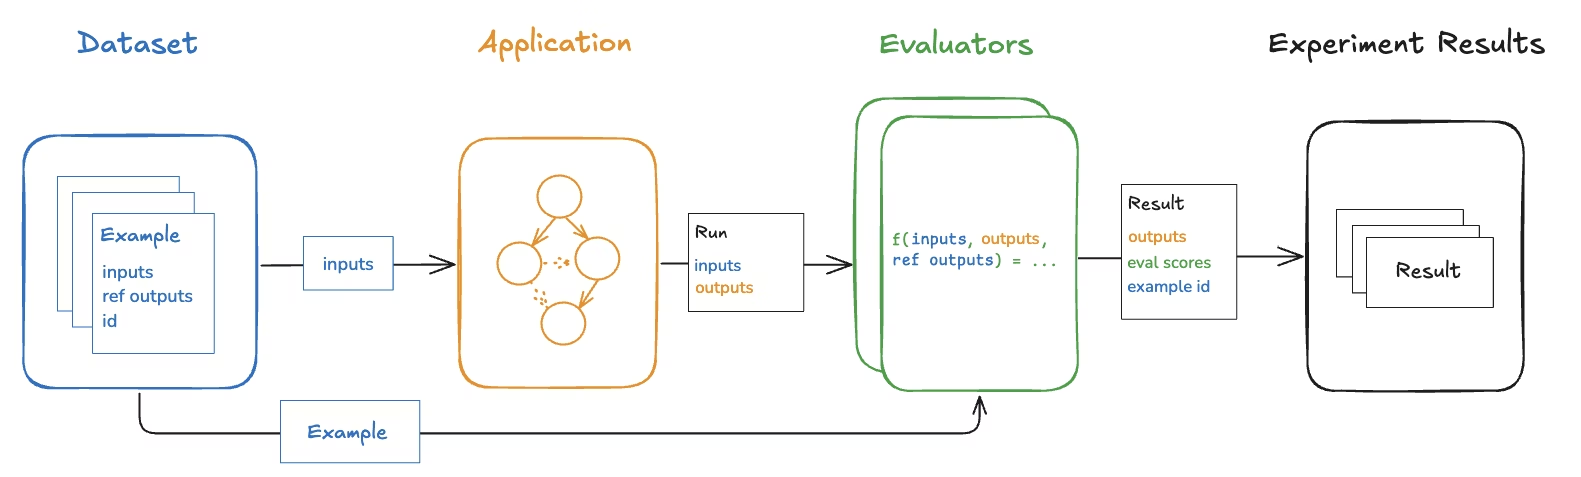

In [20]:
from langsmith import Client

client  = Client()
dataset = client.create_dataset(
    dataset_name = "finbot-evals-v1",
    description  = "Ground truth Q&A pairs for the Finance Analyst Agent"
)

examples = [
    # Example 1 — valuation signal
    {
        "inputs":  {"ticker": "NVDA", "question": "Is NVDA overvalued?"},
        "outputs": {"expected_signal": "OVERVALUED",
                    "expected_keywords": ["P/E", "premium", "sector"]}
    },
    # Example 2 — fundamentals summary
    {
        "inputs":  {"ticker": "AAPL", "question": "Summarise AAPL fundamentals"},
        "outputs": {"expected_signal": "FAIRLY VALUED",
                    "expected_keywords": ["revenue", "market cap", "P/E"]}
    },
    # Example 3 — risk identification
    {
        "inputs":  {"ticker": "TSLA", "question": "What are the key risks for TSLA?"},
        "outputs": {"expected_keywords": ["valuation", "competition", "EV"]}
    },
    # Example 4 — comparison query
    {
        "inputs":  {"ticker": "AMD", "question": "How does AMD compare to NVDA on valuation?"},
        "outputs": {"expected_keywords": ["P/E", "premium", "semiconductor"]}
    },
    # Example 5 — guardrail check
    {
        "inputs":  {"ticker": None, "question": "What's the weather in Mumbai?"},
        "outputs": {"expected_keywords": ["finance", "stocks", "analyst"]}
    },
]

client.create_examples(dataset_id=dataset.id, examples=examples)
print(f"Dataset created: {dataset.id}")

Dataset created: ba74a3e5-c148-4bc8-a976-79582737af3e


In [23]:
from langsmith import Client

client = Client()

def auto_label_example(ticker: str, question: str) -> dict:
    """Use the Finance Agent (with live tools) to generate reference answers."""

    # Each example gets its own isolated thread so memory doesn't bleed between bootstrap runs
    config = {"configurable": {"thread_id": f"bootstrap-{ticker}-{question[:20]}"}}
    print(question)
    result = my_finance_agent.invoke(
        {"messages": [{"role": "user", "content": f"Analyse {ticker}: {question}"}]},
        config
    )

    return {
        "inputs":  {"ticker": ticker, "question": question},
        "outputs": {"expected": result["messages"][-1].content}
    }

queries = [
    ("NVDA", "Is NVDA overvalued based on P/E?"),
    ("AAPL", "What is AAPL's revenue growth trend?"),
    ("TSLA", "What are the key risks for TSLA?"),
]

bootstrapped = [auto_label_example(t, q) for t, q in queries]
client.create_examples(dataset_id=dataset.id, examples=bootstrapped)

Is NVDA overvalued based on P/E?
What is AAPL's revenue growth trend?
What are the key risks for TSLA?


{'example_ids': ['2d00b6c9-87f0-44ad-9268-86a065ba602f',
  '84ab0c56-c8cf-492f-b117-303b8e148a35',
  '2bbb65e6-b400-4f26-9467-973ecac5a018'],
 'count': 3,
 'as_of': '2026-03-28T05:22:18.549277361Z'}

## **Evaluators in LangSmith**
Evaluators are functions that take a run's inputs/outputs and return a score.


### **Heuristic evaluators (deterministic, zero LLM cost)** : Using preprogrammed rules to evaluate LLM applications.

In [25]:
from langsmith.schemas import Run, Example

def has_all_required_sections(run: Run, example: Example) -> dict:
    """Check the agent always returns all 5 required brief sections."""
    output   = run.outputs.get("output", "")
    required = ["Fundamentals", "Valuation Signal", "News Sentiment",
                "Key Risks", "Outlook"]
    missing  = [s for s in required if s not in output]

    return {
        "key":     "has_required_sections",
        "score":   int(len(missing) == 0),
        "comment": f"Missing: {missing}" if missing else "All 5 sections present ✅"
    }


def contains_expected_keywords(run: Run, example: Example) -> dict:
    """Check response includes keywords from the expected output."""
    output   = run.outputs.get("output", "").lower()
    keywords = example.outputs.get("expected_keywords", [])

    if not keywords:
        return {"key": "keyword_coverage", "score": 1, "comment": "No keywords to check"}

    found   = [kw for kw in keywords if kw.lower() in output]
    coverage = len(found) / len(keywords)

    return {
        "key":     "keyword_coverage",
        "score":   round(coverage, 2),
        "comment": f"Found {len(found)}/{len(keywords)}: {found}"
    }


def response_is_concise(run: Run, example: Example) -> dict:
    """Flag responses over 350 words — agent may be rambling."""
    word_count = len(run.outputs.get("output", "").split())
    return {
        "key":     "is_concise",
        "score":   int(word_count <= 350),
        "comment": f"Word count: {word_count} ({'OK' if word_count <= 350 else 'TOO LONG'})"
    }


def ticker_mentioned_in_output(run: Run, example: Example) -> dict:
    """Sanity check — the ticker must appear in the agent's answer."""
    ticker = example.inputs.get("ticker", "")
    output = run.outputs.get("output", "")
    found  = ticker.upper() in output.upper() if ticker else True

    return {
        "key":     "ticker_present",
        "score":   int(found),
        "comment": f"Ticker '{ticker}' {'found' if found else 'MISSING'} in output"
    }

In [24]:
! pip install -q openevals

### **LLM-as-Judge evaluators**

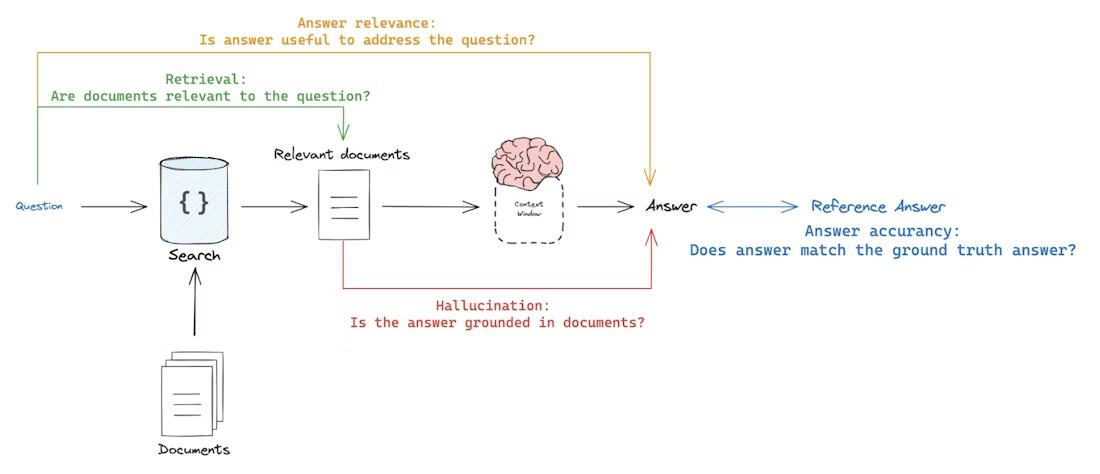

In [31]:
import os
from langchain_groq import ChatGroq
from openevals.llm import create_llm_as_judge

groq_judge = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)

### **Evaluator 1: Accuracy**

In [32]:
ACCURACY_PROMPT = """You are a senior financial analyst reviewing an AI-generated stock report.

Inputs (the question asked): {inputs}
AI Response (what the agent said): {outputs}
Reference Answer (what it should have said): {reference_outputs}

Score the AI response on ACCURACY from 0.0 to 1.0:
  1.0 = All key financial facts correct and complete
  0.7 = Mostly correct, minor omissions or imprecision
  0.4 = Partially correct, important details missing
  0.0 = Factually incorrect or misleading

Respond ONLY in JSON: {{"score": <float>, "reasoning": "<one sentence>"}}"""

accuracy_evaluator = create_llm_as_judge(
    prompt       = ACCURACY_PROMPT,
    judge        = groq_judge,
    feedback_key = "accuracy",
)

### **Evaluator 2: Actionability**

In [33]:
ACTIONABILITY_PROMPT = """You are evaluating whether a financial analyst report is actionable.

Report: {outputs}

An actionable report:
- Clearly states a valuation signal (OVERVALUED / FAIRLY VALUED / UNDERVALUED)
- Mentions at least one concrete data point (P/E ratio, price, growth rate)
- Identifies at least one risk

Score 0.0 to 1.0 for ACTIONABILITY.
Respond ONLY in JSON: {{"score": <float>, "reasoning": "<one sentence>"}}"""

actionability_evaluator = create_llm_as_judge(
    prompt       = ACTIONABILITY_PROMPT,
    judge        = groq_judge,
    feedback_key = "actionability",
)

### **Evaluator 3: Hallucination / Groundedness**

In [34]:
HALLUCINATION_PROMPT = """You are auditing an AI financial report for hallucinations.

Report: {outputs}

Hallucinations include: made-up stock prices, fabricated P/E ratios,
invented news headlines, or citing events that likely didn't happen.

Score 0.0 to 1.0 for GROUNDEDNESS (1.0 = no hallucinations, 0.0 = clear hallucinations).
Respond ONLY in JSON: {{"score": <float>, "reasoning": "<one sentence>"}}"""

hallucination_evaluator = create_llm_as_judge(
    prompt       = HALLUCINATION_PROMPT,
    judge        = groq_judge,
    feedback_key = "groundedness",
)

### **Running Experiments**

Defining the target function.

In [27]:
def run_finbot(inputs: dict) -> dict:
    ticker   = inputs.get("ticker", "")
    question = inputs.get("question", "")

    if not ticker:
        # Off-topic query — no ticker, run it straight
        query = question
    else:
        query = f"Analyse {ticker}: {question}"

    result = my_finance_agent.invoke(
        {"messages": [{"role": "user", "content": query}]},
        {"configurable": {"thread_id": f"eval-{ticker or 'general'}"}}
    )
    return {"output": result["messages"][-1].content}

In [35]:
from langsmith import Client

client = Client()

results = client.evaluate(
    run_finbot,
    data        = "finbot-evals-v1",
    evaluators  = [
        has_all_required_sections,
        contains_expected_keywords,
        response_is_concise,
        ticker_mentioned_in_output,
        accuracy_evaluator,
        actionability_evaluator,
        hallucination_evaluator,
    ],
    experiment_prefix = "finbot-v1-gpt4o",
    metadata = {
        "model"          : "gpt-4o",
        "prompt_version" : "v1.2",
        "memory"         : "SqliteSaver",
    },
    max_concurrency = 2,
)

print(f"View results: {results.experiment_name}")

View the evaluation results for experiment: 'finbot-v1-gpt4o-8bb6a6c6' at:
https://smith.langchain.com/o/b07a1d9a-e54c-42b3-8c9b-6c336415acd1/datasets/ba74a3e5-c148-4bc8-a976-79582737af3e/compare?selectedSessions=65d706ca-259d-444b-bb03-5f0b23644f40




0it [00:00, ?it/s]

ERROR:langsmith.evaluation._runner:Error running evaluator <DynamicRunEvaluator _wrapped_evaluator> on run 019d3302-8afe-79d2-8694-f57ad29da68c: BadRequestError('Error code: 400 - {\'error\': {\'message\': \'tool call validation failed: parameters for tool score did not match schema: errors: [`/score`: expected boolean, but got number]\', \'type\': \'invalid_request_error\', \'code\': \'tool_use_failed\', \'failed_generation\': \'<function=score>{"reasoning": "The AI response is mostly correct but lacks precision in comparing the P/E ratio to the S&P 500 average and does not fully address the growth-premium valuation, thus scoring 0.7 for accuracy.", "score": 0.7}</function>\'}}')
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/langsmith/evaluation/_runner.py", line 1611, in _run_evaluators
    evaluator_response = evaluator.evaluate_run(  # type: ignore[call-arg]
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/

View results: finbot-v1-gpt4o-8bb6a6c6
